# **Feature Engineering**

## Objective

The objective of this notebook is to transform cleaned delivery data into machine-learning-ready features that improve predictive performance and operational understanding.

---

## Key Goals

- Create distance-based delivery features
- Transform datetime variables
- Engineer operational indicators
- Prepare features for machine learning
- Store final Gold-layer dataset

In [1]:
silver_df = spark.read.parquet(
    "abfss://f3654803-0ae2-46c6-b5e3-bf931741cfac@onelake.dfs.fabric.microsoft.com/3fed2a27-9ec6-4038-9e8a-f3e0b408ce78/Files/silver/cleaned_delivery_data"
)

display(silver_df)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 3, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 90eb5ebb-726b-4027-b6c8-4c30793eed79)

In [2]:
pdf = silver_df.toPandas()

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 4, Finished, Available, Finished, False)

In [3]:
import pandas as pd
import numpy as np

from math import radians, sin, cos, sqrt, atan2

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 5, Finished, Available, Finished, False)

#  _Distance Feature Engineering_

Delivery distance is calculated using the Haversine formula based on pickup and drop coordinates.

In [4]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 6, Finished, Available, Finished, False)

In [5]:
pdf["Distance_km"] = pdf.apply(
    lambda row: haversine(
        row["Store_Latitude"],
        row["Store_Longitude"],
        row["Drop_Latitude"],
        row["Drop_Longitude"]
    ),
    axis=1
)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 7, Finished, Available, Finished, False)

In [6]:
pdf[["Distance_km"]].head()

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 8, Finished, Available, Finished, False)

,Distance_km
0,13.773738
1,3.040642
2,6.218002
3,10.923267
4,12.463883


### Feature Insight

Delivery distance is one of the most important logistics variables influencing operational delivery time.

In [7]:
import dateutil

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 9, Finished, Available, Finished, False)

#  _Datetime Feature Transformation_

Datetime variables are converted into machine-learning-friendly operational features.

In [8]:
pdf["Order_Date"] = pd.to_datetime(
    pdf["Order_Date"],
    errors="coerce"
)

pdf["Order_Time"] = pd.to_datetime(
    pdf["Order_Time"],
    errors="coerce"
)

pdf["Pickup_Time"] = pd.to_datetime(
    pdf["Pickup_Time"],
    errors="coerce"
)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 10, Finished, Available, Finished, False)

/tmp/ipykernel_6330/2144574591.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pdf["Order_Time"] = pd.to_datetime(


In [9]:
print(
    pdf[[
        "Order_Date",
        "Order_Time",
        "Pickup_Time"
    ]].isnull().sum()
)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 11, Finished, Available, Finished, False)

Order_Date      0
Order_Time     91
Pickup_Time     0
dtype: int64


In [10]:
pdf = pdf.dropna(
    subset=[
        "Order_Date",
        "Order_Time",
        "Pickup_Time"
    ]
)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 12, Finished, Available, Finished, False)

### Transformation Insight

Rows containing invalid datetime values were removed to ensure reliable feature generation.

#  _Operational Feature Engineering_

Operational indicators such as weekend activity and delivery timing are engineered to capture delivery behavior patterns.

In [11]:
pdf["order_hour"] = pdf["Order_Time"].dt.hour

pdf["pickup_hour"] = pdf["Pickup_Time"].dt.hour

pdf["day_of_week"] = pdf["Order_Date"].dt.day_name()

pdf["is_weekend"] = pdf["day_of_week"].isin(
    ["Saturday", "Sunday"]
).astype(int)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 13, Finished, Available, Finished, False)

#  _Rush Hour Feature Engineering_

Rush-hour indicators are engineered to capture high-congestion operational periods.

In [12]:
pdf["is_rush_hour"] = pdf["order_hour"].apply(
    lambda x: 1 if x in [8,9,10,17,18,19] else 0
)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 14, Finished, Available, Finished, False)

In [13]:
pdf.head()

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 15, Finished, Available, Finished, False)

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Vehicle,Area,Delivery_Time,Category,Distance_km,order_hour,pickup_hour,day_of_week,is_weekend,is_rush_hour
0,pqya338067587,36,4.7,18.927584,72.832585,19.017584,72.922585,2022-04-04,2026-05-11 23:40:00,2026-05-10 23:50:00,...,van,Metropolitian,145,Clothing,13.773738,23,23,Monday,0,0
1,njfz936670348,27,4.7,21.175975,72.795503,21.195975,72.815503,2022-03-15,2026-05-11 10:55:00,2026-05-10 11:10:00,...,scooter,Urban,60,Sports,3.040642,10,11,Tuesday,0,1
2,zzsx562940707,39,4.8,12.310972,76.659264,12.350972,76.699264,2022-04-01,2026-05-11 12:30:00,2026-05-10 12:45:00,...,motorcycle,Metropolitian,140,Cosmetics,6.218002,12,12,Friday,0,0
3,fkyd365052251,39,4.7,10.035573,76.336958,10.105573,76.406958,2022-02-14,2026-05-11 18:30:00,2026-05-10 18:35:00,...,motorcycle,Urban,105,Cosmetics,10.923267,18,18,Monday,0,1
4,lyyj446897623,30,4.2,11.025083,77.015393,11.105083,77.095393,2022-03-02,2026-05-11 19:20:00,2026-05-10 19:30:00,...,scooter,Metropolitian,245,Home,12.463883,19,19,Wednesday,0,1


#  Feature Validation Analysis

This section validates whether engineered features exhibit meaningful relationships with delivery performance.

# Distance Feature Validation

Hypothesis

Longer delivery distances increase delivery duration due to increased travel requirements.

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 16, Finished, Available, Finished, False)

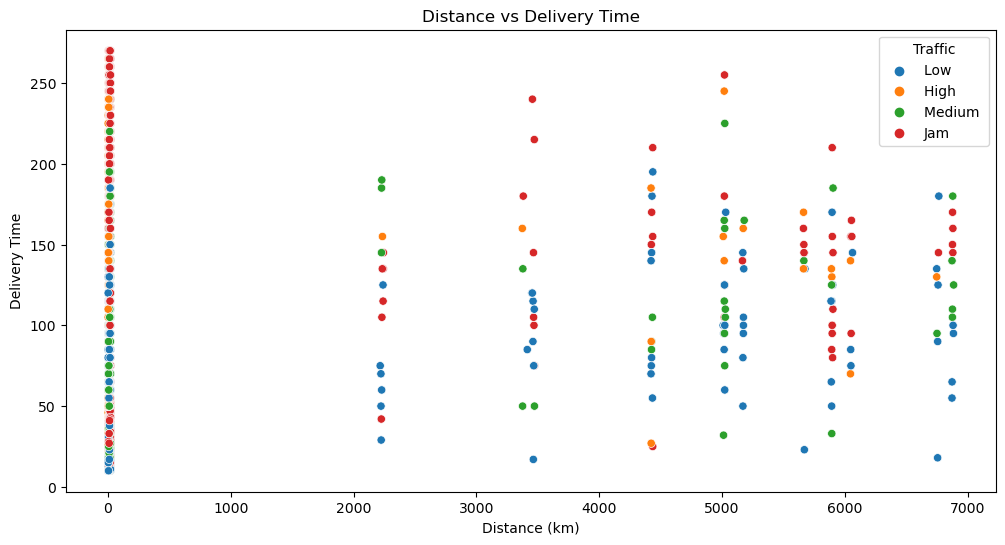

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.scatterplot(
    x="Distance_km",
    y="Delivery_Time",
    hue="Traffic",
    data=pdf
)

plt.title("Distance vs Delivery Time")

plt.xlabel("Distance (km)")

plt.ylabel("Delivery Time")

plt.savefig(
    "/lakehouse/default/Files/screenshots/distance vs delivery time.png",
    bbox_inches="tight"
)

plt.show()

Distance exhibits a strong positive relationship with delivery time performance, validating it as a meaningful predictive feature.

# Rush Hour Feature Validation

 Hypothesis

Rush-hour operational periods significantly increase delivery delays.

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 17, Finished, Available, Finished, False)

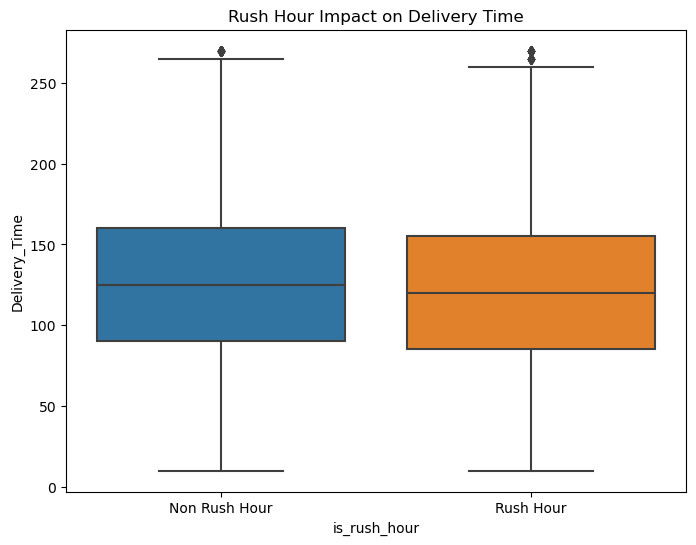

In [15]:
# Rush Hour Analysis
plt.figure(figsize=(8,6))

sns.boxplot(
    x="is_rush_hour",
    y="Delivery_Time",
    data=pdf
)

plt.title("Rush Hour Impact on Delivery Time")

plt.xticks(
    [0,1],
    ["Non Rush Hour", "Rush Hour"]
)

plt.savefig(
    "/lakehouse/default/Files/screenshots/Rush Hour Impact.png",
    bbox_inches="tight"
)


plt.show()


Rush-hour conditions increase operational delivery variability and delays.

# Weekend Feature Validation

Hypothesis

Weekend operational patterns may influence delivery efficiency differently from weekdays.

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 18, Finished, Available, Finished, False)

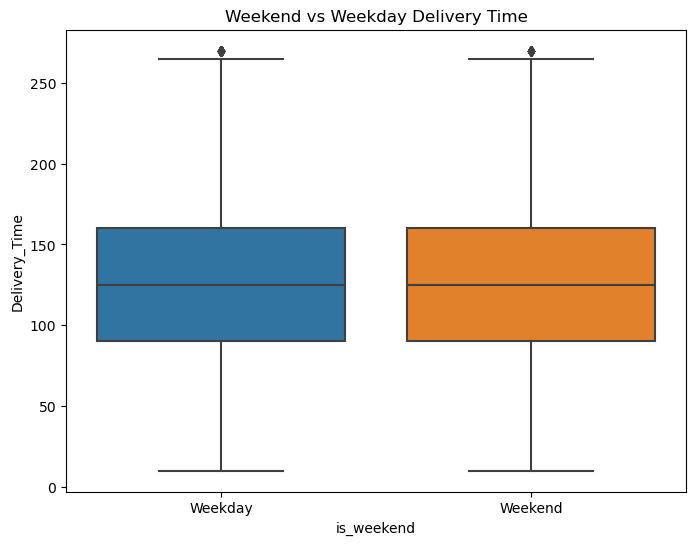

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="is_weekend",
    y="Delivery_Time",
    data=pdf
)

plt.title("Weekend vs Weekday Delivery Time")

plt.xticks(
    [0,1],
    ["Weekday", "Weekend"]
)

plt.savefig(
    "/lakehouse/default/Files/screenshots/weekday vs weekend.png",
    bbox_inches="tight"
)

plt.show()


Weekend delivery behavior exhibits moderate variation compared to weekday operations.

#  <u>**Gold Layer Storage**</u>

The final feature-engineered dataset is stored in the Gold layer for downstream machine learning workflows.

In [17]:
gold_df = spark.createDataFrame(pdf)

gold_df.write.mode("overwrite").parquet(
    "Files/gold/featured_delivery_data"
)

display(gold_df)

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 3ed074cc-707a-4998-bfa7-1a7b39dc81b1)

#  Final Engineered Features Preview

In [18]:
pdf[[
    "Distance_km",
    "order_hour",
    "pickup_hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour"
]].head()

StatementMeta(, 63bca9cc-3c16-42b0-ac8b-b08247ad1c5b, 20, Finished, Available, Finished, False)

,Distance_km,order_hour,pickup_hour,day_of_week,is_weekend,is_rush_hour
0,13.773738,23,23,Monday,0,0
1,3.040642,10,11,Tuesday,0,1
2,6.218002,12,12,Friday,0,0
3,10.923267,18,18,Monday,0,1
4,12.463883,19,19,Wednesday,0,1


# <u>**Key Feature Engineering Insights**</u>

- Delivery distance emerged as a major predictive operational feature.
- Rush-hour indicators capture traffic-driven delivery variability.
- Weekend operational behavior exhibits moderate delivery variation.
- Datetime transformation improved temporal feature representation.
- Engineered features provide meaningful operational signals for machine learning models.

---

# <u>**Next Steps**</u>

The engineered Gold-layer dataset will be used for:
- preprocessing
- machine learning model training
- hyperparameter tuning
- model evaluation
- deployment workflows